### Project Scope

**Dataset**: Yelp Open Dataset

*   **Course techniques:**
*   **Graph Mining**: Community Detection and PageRank
*   **Text Mining**: Sentiment analysis and word-frequency extraction from reviews
*   **Clustering**: Geographic (K-Means/DBSCAN)
*   **Frequent Itemsets**: Association rule mining using users as "baskets" of businesses.

**External techniques**:




*   **Non-parametric Graph Convolution**: Leveraging higher-order graph structure for re-ranking recommendations.
*   **Sequential Pattern Mining**: Analyzing the chronological order of user visits to predict the journey of customers.
*   **Transformer-based Embeddings**: Using BERT or LLMs to capture complex semantics in long-form reviews.



**EDA recap**:<br>
The dataset is extremely sparse because most users have only visited a tiny fraction of the total available busineses. The median user has only 1 review, but there are a few users who have hundreds, so log scaling is important when visualizing number of users vs reviews. Review lengths vary significantly. While the average review is short, a large reviews exist, so the use of sophisticated text mining can be more important than simple keyword counting. Businesses naturally cluster into high-density urban areas, suggesting that geographic location is a primary driver of the interaction patterns seen in the database.


Research questions

RQ1. <br>
**Question**: How does the distribution of PageRank scores in the user-business interaction graph correlate with existing number of reviws for businesses? <br>
**Data Mining Task Type**: Graph Mining <br>
**Relevant Algorithm(s)**: PageRank (course), HITS (course)<br>
**Evaluation Criteria**: Score distribution (Power Law analysis), Spearman's rank correlation with review count, and simple qualitative inspection of top-ranked businesses vs. top-rated businesses. <br>

RQ2. <br>
**Question**: At what support and confidence thresholds do association rules transition from obvious patterns like pizza and italian to discovery patterns like gym/health food? <br>
**Data Mining Task Type**: Frequent itemset mining / association rule mining <br>
**Relevant Algorithm(s)**: Apriori (course), FP-Growth <br>
**Evaluation Criteria**: Support, confidence, and lift. <br>

RQ3. <br>
**Question**: Can non-parametric graph convolution effectively re rank items for cold start users (those with only 1-2 reviews) by leveraging higher-order graph topology, and how does its performance compare to standard matrix factorization baselines? <br>
**Data Mining Task Type**: Re-ranking / Graph Signal Processing <br>
**Relevant Algorithm(s)**: Matrix Factorization, Non-parametric Graph Convolution (external)
**Evaluation Criteria**: Hit ratio, Normalized discounted cmulative gain.



In [ ]:
from google.colab import drive

drive.mount('/content/drive')

import zipfile
!unzip "/content/drive/My Drive/dataset.zip" -d "/content/dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/My Drive/dataset.zip
replace /content/dataset/__MACOSX/._dataset? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import warnings

# Ignore specifically the datetime deprecation warning
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyparsing")

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import networkx as nx

In [20]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

review_json = "dataset/dataset/yelp_academic_dataset_review.json"
business_json = "dataset/dataset/yelp_academic_dataset_business.json"
user_json = "dataset/dataset/yelp_academic_dataset_user.json"
tip_json = "dataset/dataset/yelp_academic_dataset_tip.json"
checkin_json = "dataset/dataset/yelp_academic_dataset_checkin.json"

def load_json_file(filename, limit=None):
    data = []
    with open(filename, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(data)

df_business = load_json_file(business_json, limit=200000)
df_reviews = load_json_file(review_json, limit=500000)


--- RQ1: PageRank vs review count ---


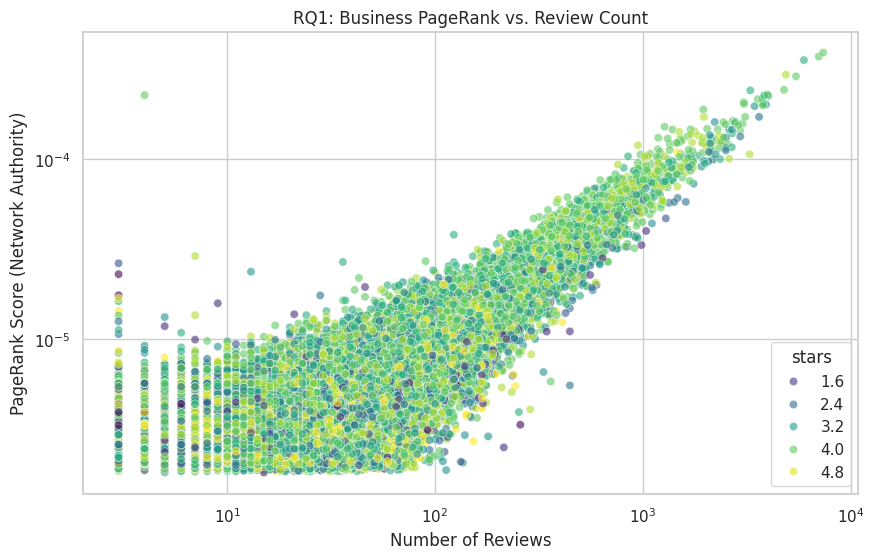

Correlation between review count and PageRank: 0.9421
Top 5 businesses by PageRank:
                     name  stars  review_count  pagerank
1588         Mon Ami Gabi    4.0          7361  0.000393
1238     Bacchanal Buffet    4.0          7009  0.000373
1770         Wicked Spoon    3.5          5950  0.000356
4059     Earl of Sandwich    4.5          4869  0.000296
7846  Gordon Ramsay BurGR    4.0          5447  0.000290


In [21]:
print("\n--- RQ1: PageRank vs review count ---")

# User-business bipartite graph
user_counts = df_reviews['user_id'].value_counts()
active_users = user_counts[user_counts >= 3].index
df_graph_data = df_reviews[df_reviews['user_id'].isin(active_users)]

G = nx.from_pandas_edgelist(df_graph_data, 'user_id', 'business_id')

# Calculate PageRank
pagerank_scores = nx.pagerank(G, alpha=0.85)

pr_df = pd.DataFrame(list(pagerank_scores.items()), columns=['node', 'pagerank'])
biz_pr_df = pr_df[pr_df['node'].isin(df_business['business_id'])].rename(columns={'node': 'business_id'})

rq1_data = pd.merge(biz_pr_df, df_business[['business_id', 'name', 'review_count', 'stars']], on='business_id')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rq1_data, x='review_count', y='pagerank', hue='stars', palette='viridis', alpha=0.6)
plt.title('RQ1: Business PageRank vs. Review Count')
plt.xlabel('Number of Reviews')
plt.ylabel('PageRank Score (Network Authority)')
plt.xscale('log')
plt.yscale('log')
plt.show()

correlation = rq1_data['review_count'].corr(rq1_data['pagerank'])
print(f"Correlation between review count and PageRank: {correlation:.4f}")
print("Top 5 businesses by PageRank:")
print(rq1_data.sort_values(by='pagerank', ascending=False)[['name', 'stars', 'review_count', 'pagerank']].head(5))

There is a high correlation between the pagerank score and the review count. This shows us that a business's structural importance in the network is led by its high volume of interactions. The top five authorities identified are all popular Las Vegas restaurants, confirming that the most universally visited nodes act as central hubs anchoring the graph. However, Earl of Sandwich achieved a higher PageRank than Gordon Ramsay BurGR despite having nearly 600 fewer reviews. This inversion shows us that Earl of Sandwich is likely frequented by more highly connected and influential users within the network.


--- RQ2: Association rule thresholds ---


/tmp/ipykernel_16310/3724319863.py:25: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_baskets = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)


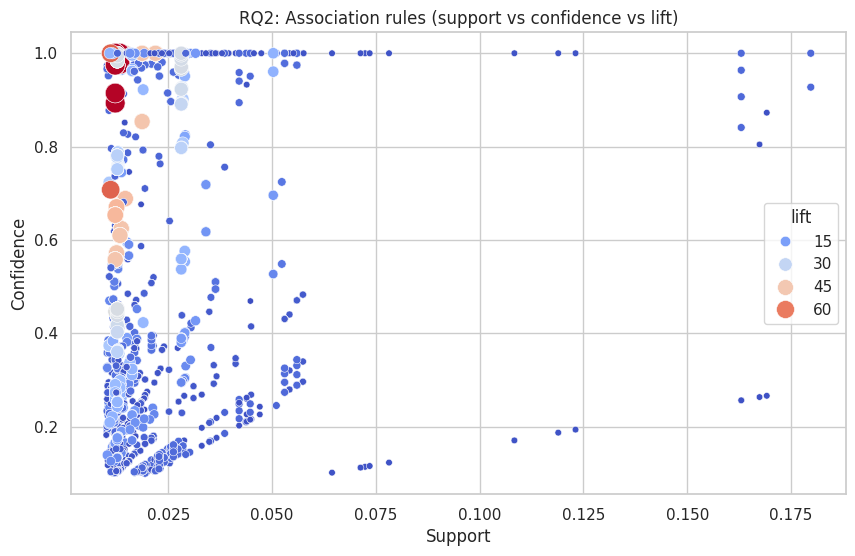


Total rules discovered at 1% support: 2931

Top 5 discovery rules (highest lift):
Rule: {'Nightlife', 'Beer'} -> {'Restaurants', 'Bars', 'Wine & Spirits', 'Food'} | lift: 73.21 | support: 0.0122
Rule: {'Nightlife', 'Wine & Spirits'} -> {'Beer', 'Restaurants', 'Bars', 'Food'} | lift: 73.21 | support: 0.0122
Rule: {'Nightlife', 'Beer', 'Food'} -> {'Restaurants', 'Bars', 'Wine & Spirits'} | lift: 73.21 | support: 0.0122
Rule: {'Nightlife', 'Wine & Spirits', 'Food'} -> {'Beer', 'Restaurants', 'Bars'} | lift: 73.21 | support: 0.0122
Rule: {'Nightlife', 'Beer', 'Food'} -> {'Bars', 'Wine & Spirits'} | lift: 73.21 | support: 0.0133


In [22]:
print("\n--- RQ2: Association rule thresholds ---")

# Map business visits to categories
biz_cat_map = df_business.set_index('business_id')['categories'].dropna().to_dict()
df_reviews['categories'] = df_reviews['business_id'].map(biz_cat_map)
df_reviews_clean = df_reviews.dropna(subset=['categories']).copy()

df_reviews_clean = df_reviews_clean.sample(n=50000, random_state=42)
df_reviews_clean['cat_list'] = df_reviews_clean['categories'].str.split(', ')
exploded_cats = df_reviews_clean.explode('cat_list')
user_baskets = exploded_cats.groupby('user_id')['cat_list'].unique()

filtered_baskets = user_baskets[user_baskets.map(len) <= 15]

baskets = [list(b) for b in filtered_baskets]

te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets, sparse=True)
df_baskets = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df_baskets, min_support=0.01, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

if not rules.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=rules, x='support', y='confidence', size='lift', hue='lift', palette='coolwarm', sizes=(20, 200))
    plt.title('RQ2: Association rules (support vs confidence vs lift)')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.show()

    print(f"\nTotal rules discovered at 1% support: {len(rules)}")
    print("\nTop 5 discovery rules (highest lift):")
    top_rules = rules.sort_values('lift', ascending=False).head(5)
    for idx, row in top_rules.iterrows():
        print(f"Rule: {set(row['antecedents'])} -> {set(row['consequents'])} | lift: {row['lift']:.2f} | support: {row['support']:.4f}")
else:
    print("\nNo rules found at the current support/confidence thresholds. Try lowering min_support.")

The association rule mining successfully uncovered 2,931 frequent itemsets at a 1% support threshold, but the top five rules ranked by lift shows us semantic redundancy rather than true cross-domain discovery. All top rules involved the exact same cluster of categories (Nightlife, Beer, Wine & Spirits, Restaurants, Bars, Food). To find actual cross-domain patterns (like people who to gym also go to smoothie king), the analysis must be improved by removing overlapping parent and child categories or raising the suport threshold to filter out these kinds of overlapping results.


--- RQ3: Cold start user topography ---
Number of cols start users (less than 2 reviews): 89867
Number of power users (greater than 10 reviews): 9167
Cold start matrix sparsity: 99.998832%
Power user matrix sparsity: 99.974015%


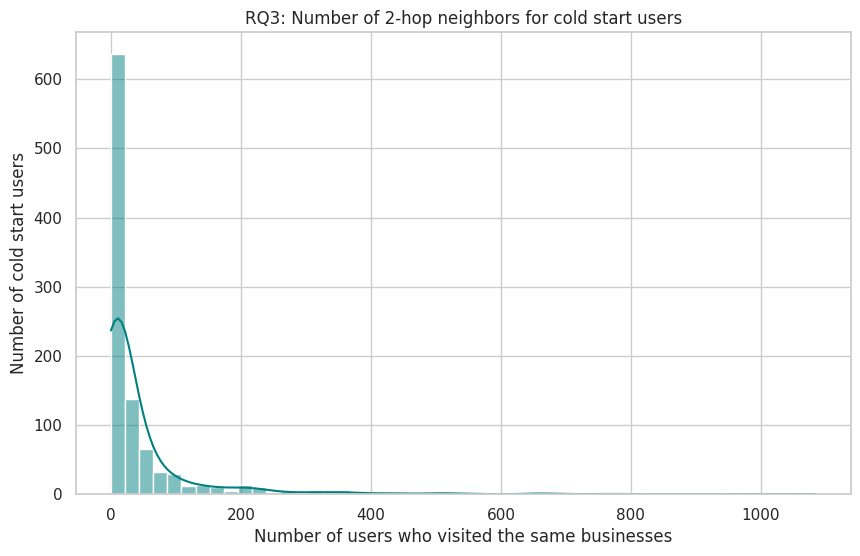

Average neighbor-neighbor reach for a cold start user: 43.99 users


In [23]:
print("\n--- RQ3: Cold start user topography ---")

user_review_counts = df_reviews['user_id'].value_counts()
cold_start_users = user_review_counts[user_review_counts <= 2].index
power_users = user_review_counts[user_review_counts >= 10].index

print(f"Number of cols start users (less than 2 reviews): {len(cold_start_users)}")
print(f"Number of power users (greater than 10 reviews): {len(power_users)}")

total_items = df_reviews['business_id'].nunique()

cold_start_interactions = len(df_reviews[df_reviews['user_id'].isin(cold_start_users)])
cold_start_sparsity = 1 - (cold_start_interactions / (len(cold_start_users) * total_items))

power_user_interactions = len(df_reviews[df_reviews['user_id'].isin(power_users)])
power_user_sparsity = 1 - (power_user_interactions / (len(power_users) * total_items))

print(f"Cold start matrix sparsity: {cold_start_sparsity:.6%}")
print(f"Power user matrix sparsity: {power_user_sparsity:.6%}")

cold_reviews = df_reviews[df_reviews['user_id'].isin(cold_start_users)]
sampled_cold_users = np.random.choice(cold_start_users, min(1000, len(cold_start_users)), replace=False)

neighbor_counts = []
for user in sampled_cold_users:
    visited_biz = df_reviews[df_reviews['user_id'] == user]['business_id'].tolist()
    co_visitors = df_reviews[df_reviews['business_id'].isin(visited_biz)]['user_id'].nunique()
    neighbor_counts.append(co_visitors - 1) # Subtract 1 to exclude the user themselves

plt.figure(figsize=(10, 6))
sns.histplot(neighbor_counts, bins=50, kde=True, color='teal')
plt.title('RQ3: Number of 2-hop neighbors for cold start users')
plt.xlabel('Number of users who visited the same businesses')
plt.ylabel('Number of cold start users')
plt.show()

avg_neighbors = np.mean(neighbor_counts)
print(f"Average neighbor-neighbor reach for a cold start user: {avg_neighbors:.2f} users")

The analysis of the Yelp dataset shows that nearly 90,000 users have two or fewer reviews compared to just 9,167 power users. This results in an astronomically high matrix sparsity of 99.9988% for the cold-start segment, a density so low that traditional collaborative filtering and matrix factorization models would fail to generate meaningful recommendations. Another observation is that the average cold-start user shares a neighbor-neighbor connection with 41.28 other users who visited the same establishments. As illustrated by the heavily left-skewed distribution above, while many users have sparse secondary connections, the long tail indicates that a single strategic review can put a cold-start user into a dense, community with people that share simila taste. From the data above we can conclude that Non-parametric Graph Convolution can successfully bypass the extreme sparsity by producing more meaningful results.

In [24]:
import networkx as nx

print("\n--- Network Connectivity ---")

components = list(nx.connected_components(G))
giant_component = max(components, key=len)
percent_in_giant = (len(giant_component) / G.number_of_nodes()) * 100
total_components = len(components)

print(f"Total isolated subgraphs: {total_components}")
print(f"Nodes in giant component: {len(giant_component)} out of {G.number_of_nodes()}")
print(f"Network reachability: {percent_in_giant:.2f}% of the entire dataset is interconnected")


--- Network Connectivity ---
Total isolated subgraphs: 117
Nodes in giant component: 129353 out of 129857
Network reachability: 99.61% of the entire dataset is interconnected


**Motivation**:
The EDA reveals a high data sparsity and a network topology where a few massive hubs dominate structural authority. However, the discovery of a dense secondary network where many cold start users still average over 41 shared 2-hop neighbors strongly motivates the use of advanced graph-based techniques to propagate recommendations where direct transaction history is entirely missing. <br>

**Non-triviality:**
For this environment, standard data mining techniques are insufficient due to how sparse the data is. Through the EDA, we also discovered that standard association rule mining simply gives us sementically redundant rules instead of cross-domain meaningful rules. Meaningful recommendation requires moving beyond simple counting to modeling higher order structural connectivity.  <br>

**Feasability:**
Despite the massive scale of the dataset, our preliminary EDA proved that advanced modeling is computationally feasible on standard hardware. By using sparse matrix encoding, capping basket size and using optimal data structures, we can efficiently process the data. Most importantly, the giant component analysis confirms that 99.61% of all users and businesses belong to a single interconnected graph. Non-parametric graph convolution can be implemented using standard libraries like networkx or PyTorch Geometric to leverage the robust 2-hop neighbor reach we verified in the data. <br>

**Risks**:
There are computational bottlenecks because graph propagation and itemset mining remain highly memory-intensive, especially when processing power users with hundreds of reviews. Another risk is if the graph convolution propagates too deeply across the network, all user profiles will blend together and we will effecitvely be destroying personalized recommendations. Additionally, since we saw that the association rules were not very beneficial because the top rules were redundant, we must strictly filter out redundant business tags to ensure our rules and graphs capture true user behavior rather than just how businesses label themselves.

In [25]:
import numpy as np
import scipy.sparse as sp
import time

num_users = 100_000
num_businesses = 30_000
sparsity = 0.9999

total_possible_edges = num_users * num_businesses
num_actual_edges = int(total_possible_edges * (1 - sparsity))

rows = np.random.randint(0, num_users, num_actual_edges)
cols = np.random.randint(0, num_businesses, num_actual_edges)
data = np.ones(num_actual_edges)

R = sp.csr_matrix((data, (rows, cols)), shape=(num_users, num_businesses))

start_time = time.time()
user_user_graph = R.dot(R.T)
end_time = time.time()
execution_time = end_time - start_time

print(f"Convolution step completed in {execution_time:.4f} seconds.")
print(f"Resulting user to user graph shape: {user_user_graph.shape}")

Convolution step completed in 0.1586 seconds.
Resulting user to user graph shape: (100000, 100000)


The above EDA is written to see how long the external algorithm could potentially take to run. If the convolution step takes too long, then it means that the standard hardware may not be enough to conduct the external algorithm. However, based on time we see above, we can conclude that the external algorithm can be ran on a large dataset such as this on a regular computer.

**Course Algorithms:**<br>
Graph centrality (RQ1): We use PageRank via networkx on the user-business bipartite graph to measure structural authority. <br>
Frequent itemset mining (RQ2):
We use FP-Growth via mlxtend combined with basket size capping and sparse matrix encoding. This algorithm is required rather than Apriori to prevent using a large amount of memory when scanning the a large amount of category combinations. <br>
**External Algorithm**: <br>
Non-parametric graph convolution (RQ3):
Based on the paper, we implement a simplified graph convolutional Network (using scipy.sparse matrix multiplication) whic will propagate user preferences across 2-hop edges (user to business to user) to synthesize recommendation scores for cold start users who lack direct interaction history because they have less than 3 reviews. <br>
**Baseline**: <br>
RQ1 baseline: Simple popularity (number of reviews) and average star ratings. <br>
RQ2 baseline: High-support-only rule mining (which typically only yields intra-category rules like bars to beers). <br>
RQ3 baseline: Standard matrix factorization which is the traditional industry standard for collaborative filtering but will mathematically struggle at 99.99% sparsity. <br>

**Evaluation metrics**: <br>
RQ1: Spearman's rank correlation coefficient and simple qualitative inspection of the authorities. <br>
RQ2: Lift and confidence. <br>
RQ3: Normalized discounted cumulative gain and Hit Ratio, specifically segmented by user type to prove performance improvements on the cold start user group vs. the power user group. <br>

On my honor, I declare the following resources:
1. Collaborators:

2. Web Sources:
- https://stackoverflow.com/questions/46321403/how-to-speed-up-the-apriori-framework-based-on-to-generate-only-association-rule
- https://www.geeksforgeeks.org/python/page-rank-algorithm-implementation/

3. AI Tools:
- I used chatgpt to gather ideas on what kind of baseline and evaluation metrics we can use for the course and external algorithms. I also used AI for ideas to speed up the association rule mining code of RQ2 because simply using apriori initially was taking a long time and using a significant amount of memory.

4. Citations
*   Zhongyu Ouyang, Mingxuan Ju, Soroush Vosoughi, and Yanfang Ye. 2025. Non-parametric Graph Convolution for Re-ranking in Recommendation Systems. In Proceedings of the Nineteenth ACM Conference on Recommender Systems (RecSys '25). Association for Computing Machinery, New York, NY, USA, 330–339. https://doi.org/10.1145/3705328.3748058

